<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula22d%20-%20algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

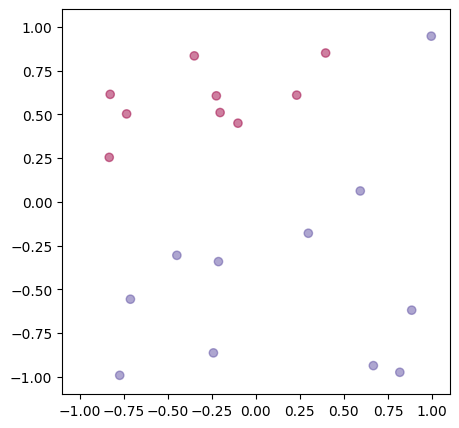

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, vector=[1,-1], bias=0.2):
  X = np.random.uniform(size=(n,2))*2-1
  y = (X@vector + bias>0)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-1.1, 1.1)
  plt.ylim(-1.1, 1.1)

plotDataset(X, y)
plt.show()

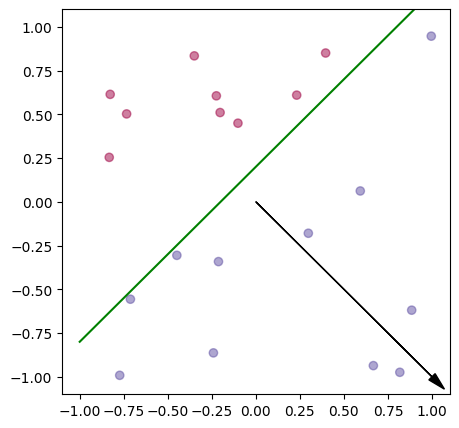

In [34]:
def plotHyperplan(vector, bias):
  xs = np.array([-1,1])
  ys = -(vector[0]*xs + bias)/vector[1]
  plt.plot(xs, ys, 'g')

def plotVector(vector):
  plt.arrow(0, 0, vector[0], vector[1], head_width=0.05, head_length=0.1, fc='k', ec='k')

plotDataset(X, y)
vector = [1,-1]
bias = 0.2
plotHyperplan(vector, bias)
plotVector(vector)
plt.show()

In [40]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class PseudoInverse(TrainingAlgorithm):
  def getW(self, X, y):
    w = np.linalg.pinv(X) @ y
    return w

Accuracy: 0.95
Weights: [ 0.14731946  0.55087627 -1.11476183]


<Figure size 500x500 with 0 Axes>

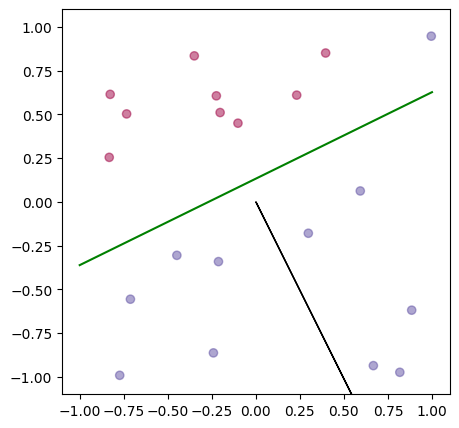

In [46]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class ShallowNeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w = self.trainingAlgorithm.getW(X, y)
    return self

  def pre_activation(self, X):
    logits = X @ self.w
    return logits

  def predict(self, X):
    X = include_bias(X)
    logits = self.pre_activation(X)
    y_pred = np.sign(logits)
    return y_pred

model = ShallowNeuralNetwork(PseudoInverse())
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

Accuracy: 0.866


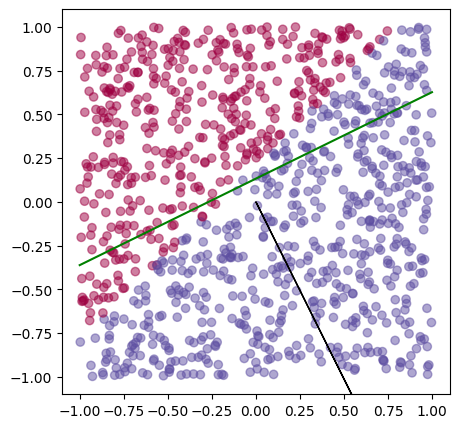

In [47]:
X_test, y_test = createDataset(1000)
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

In [44]:
class WidrowHoff(TrainingAlgorithm):
  def __init__(self, learning_rate=0.01, max_iter=100):
    self.learning_rate = learning_rate
    self.max_iter = max_iter

  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],))
    for _ in range(self.max_iter):
      y_pred = X @ w
      error = y - y_pred
      w += X.T @ error * self.learning_rate
    return w

Accuracy: 0.95
Weights: [ 0.14734323  0.55149472 -1.11443774]


<Figure size 500x500 with 0 Axes>

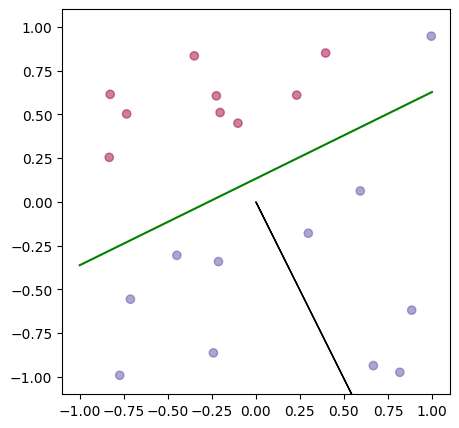

In [48]:
model = ShallowNeuralNetwork(WidrowHoff())
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

In [49]:
class Perceptron(TrainingAlgorithm):
  def __init__(self, max_iter=100):
    self.max_iter = max_iter

  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],))
    for _ in range(self.max_iter):
      y_pred = np.sign(X @ w)
      error = y - y_pred
      w += X.T @ error
    return w

Accuracy: 1.0
Weights: [  2.56199252   9.57667441 -11.44462262]


<Figure size 500x500 with 0 Axes>

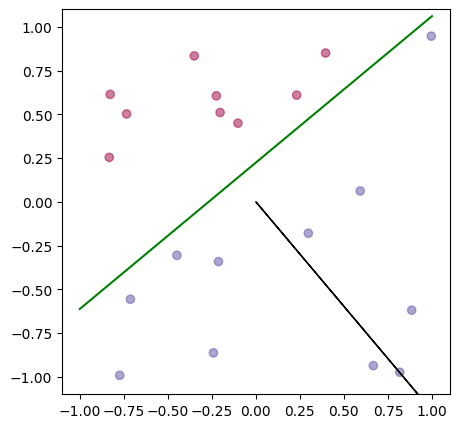

In [72]:
model = ShallowNeuralNetwork(Perceptron())
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

Accuracy: 0.969


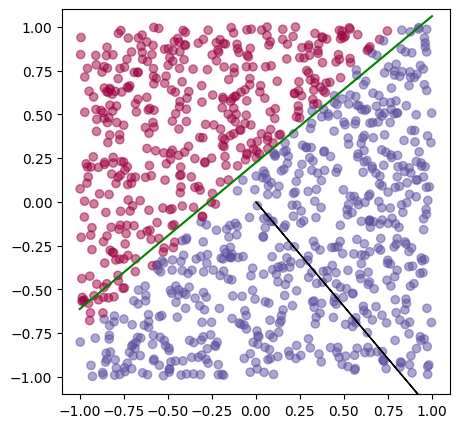

In [73]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()